
# Задание №3 – Обработка ЭЭГ сигнала
# В данной работе выполняется:
# 1. Загрузка EDF-файла и поиск момента приступа
# 2. Визуализация временной зависимости одного канала
# 3. Усреднение всех ЭЭГ-каналов
# 4. Фильтрация (удаление частот выше 60 Гц)
# 5. Построение спектрограммы и вейвлет-скейлограммы усреднённого сигнала

In [2]:
# ========== Ячейка 1: Импорт библиотек и настройка ==========
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy.signal import spectrogram
import pywt

# Параметры отображения графиков
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
# При проблемах с кириллицей можно раскомментировать следующую строку:
# plt.rcParams['font.family'] = 'DejaVu Sans'

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


In [3]:
# ========== Ячейка 2: Путь к файлу и константы ==========
# Укажите путь к вашему EDF-файлу
EDF_PATH = os.path.expanduser("~/Desktop/lab3/eeg17.edf")

# Резервные значения приступа, если аннотации отсутствуют
FALLBACK_SEIZURE_START = 100.0   # начало приступа (сек)
FALLBACK_SEIZURE_DURATION = 20.0 # длительность (сек)

# Параметры визуализации временного окна
TIME_BEFORE = 5.0    # сколько секунд показать до приступа
TIME_AFTER  = 10.0   # сколько секунд показать после начала приступа

# Частота среза ФНЧ
LOWPASS_FREQ = 60.0  # Гц

# Параметры вейвлет-преобразования
WAVELET = 'cmor1.5-1.0'   # комплексный вейвлет Морле
SCALES = np.arange(1, 128) # набор масштабов

print(f"Файл данных: {EDF_PATH}")

Файл данных: C:\Users\gsdasddj/Desktop/lab3/eeg17.edf


In [11]:
# ========== Ячейка 3: Загрузка EDF и поиск приступа ==========
print("Чтение EDF-файла...")
raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)
sfreq = raw.info['sfreq']  # частота дискретизации

print(f"Частота дискретизации: {sfreq} Гц")
print(f"Количество каналов: {len(raw.ch_names)}")
print(f"Названия каналов: {raw.ch_names}")
print(f"Длительность записи: {raw.times[-1]:.2f} сек")

# Поиск аннотации приступа
annotations = raw.annotations
seizure_onset = None
seizure_duration = None

if annotations is not None and len(annotations) > 0:
    print("\nВстроенные аннотации:")
    for desc, onset, dur in zip(annotations.description,
                                annotations.onset,
                                annotations.duration):
        print(f"  {desc}: начало {onset:.2f}с, длит. {dur:.2f}с")
    # Поиск ключевых слов
    for desc, onset, dur in zip(annotations.description,
                                annotations.onset,
                                annotations.duration):
        desc_lower = desc.lower()
        if any(kw in desc_lower for kw in ['seizure', 'sz', 'приступ', 'epileptic']):
            seizure_onset = onset
            seizure_duration = dur if dur > 0 else FALLBACK_SEIZURE_DURATION
            print(f"\nНайден приступ: '{desc}' начало {onset:.2f}с")
            break

if seizure_onset is None:
    print("\nАннотация приступа не найдена. Используются резервные значения.")
    seizure_onset = FALLBACK_SEIZURE_START
    seizure_duration = FALLBACK_SEIZURE_DURATION

print(f"Момент начала приступа: {seizure_onset:.2f} сек")

Чтение EDF-файла...


C:\Users\gsdasddj\AppData\Local\Temp\ipykernel_1752\1520971216.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)
C:\Users\gsdasddj\AppData\Local\Temp\ipykernel_1752\1520971216.py:3: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)


Частота дискретизации: 256.0 Гц
Количество каналов: 21
Названия каналов: ['EEG Fp1-Ref', 'EEG Fp2-Ref', 'EEG F3-Ref', 'EEG F4-Ref', 'EEG F7-Ref', 'EEG F8-Ref', 'EEG Fz-Ref', 'EEG C3-Ref', 'EEG C4-Ref', 'EEG Cz-Ref', 'EEG T3-Ref', 'EEG T5-Ref', 'EEG T4-Ref', 'EEG T6-Ref', 'EEG P3-Ref', 'EEG P4-Ref', 'EEG Pz-Ref', 'EEG O1-Ref', 'EEG O2-Ref', 'ECG EKG', 'Resp Effort']
Длительность записи: 5493.00 сек

Аннотация приступа не найдена. Используются резервные значения.
Момент начала приступа: 100.00 сек


Окно для визуализации: 95.00 – 110.00 сек


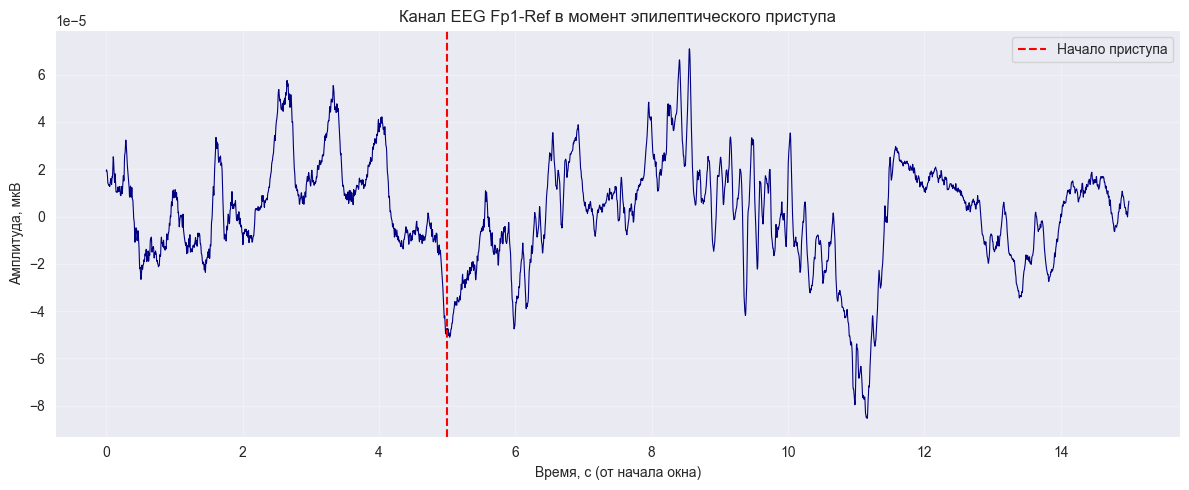

In [16]:
# %% [code]
# ========== Ячейка 4: Вырезание окна и график одного канала ==========
# Вычисляем границы временного окна
t_min = max(seizure_onset - TIME_BEFORE, 0)
t_max = min(seizure_onset + TIME_AFTER, raw.times[-1])
print(f"Окно для визуализации: {t_min:.2f} – {t_max:.2f} сек")

# Получаем данные в этом окне
crop_raw = raw.copy().crop(tmin=t_min, tmax=t_max)
data_crop, times_crop = crop_raw[:]  # data_crop: (n_channels, n_times)

# Выбираем первый доступный ЭЭГ-канал (исключая служебные)
eeg_ch_names = [ch for ch in crop_raw.ch_names
                if ch.upper() not in ['STI 014', 'EDF ANNOTATIONS']
                and 'STIM' not in ch.upper()]
if not eeg_ch_names:
    eeg_ch_names = [crop_raw.ch_names[0]]
ch_name = eeg_ch_names[0]
ch_idx = crop_raw.ch_names.index(ch_name)

# Построение временной зависимости
plt.figure()
plt.plot(times_crop, data_crop[ch_idx], linewidth=0.8, color='navy')
# 关键修正：用相对时间标注发作起点
plt.axvline(seizure_onset - t_min, color='red', linestyle='--',
            label='Начало приступа')
plt.xlabel('Время, с (от начала окна)')
plt.ylabel('Амплитуда, мкВ')
plt.title(f'Канал {ch_name} в момент эпилептического приступа')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ========== Ячейка 5: Усреднение всех ЭЭГ-каналов ==========
# Из исходного объекта raw выбираем только ЭЭГ-каналы
eeg_ch_names_full = [ch for ch in raw.ch_names
                     if ch.upper() not in ['STI 014', 'EDF ANNOTATIONS']
                     and 'STIM' not in ch.upper()]
print(f"Число ЭЭГ-каналов для усреднения: {len(eeg_ch_names_full)}")

raw_eeg = raw.copy().pick_channels(eeg_ch_names_full)
avg_signal_full = raw_eeg.get_data().mean(axis=0)  # усреднение по каналам

# Создаём новый Raw объект с одним каналом 'avg'
info_avg = mne.create_info(['avg'], sfreq, ch_types='eeg')
raw_avg = mne.io.RawArray(avg_signal_full[np.newaxis, :], info_avg)

# Выводим небольшую проверку
print(f"Форма усреднённого сигнала: {avg_signal_full.shape}")
print("Усреднение выполнено.")

Число ЭЭГ-каналов для усреднения: 21
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Creating RawArray with float64 data, n_channels=1, n_times=1406208
    Range : 0 ... 1406207 =      0.000 ...  5492.996 secs
Ready.
Форма усреднённого сигнала: (1406208,)
Усреднение выполнено.


In [14]:
# ========== Ячейка 6: Фильтрация (ФНЧ ≤ 60 Гц) ==========
print(f"Применяется фильтр низких частот с частотой среза {LOWPASS_FREQ} Гц...")
raw_avg_filtered = raw_avg.copy().filter(l_freq=None, h_freq=LOWPASS_FREQ,
                                         fir_design='firwin', verbose=False)
data_avg_filt, times_full = raw_avg_filtered[:]
data_avg_filt = data_avg_filt[0]  # одномерный массив

# Вырезаем тот же временной интервал, что и ранее
mask = (times_full >= t_min) & (times_full <= t_max)
times_crop_avg = times_full[mask]
signal_crop_avg = data_avg_filt[mask]

print("Фильтрация завершена.")

Применяется фильтр низких частот с частотой среза 60.0 Гц...
Фильтрация завершена.


Вычисление спектрограммы...


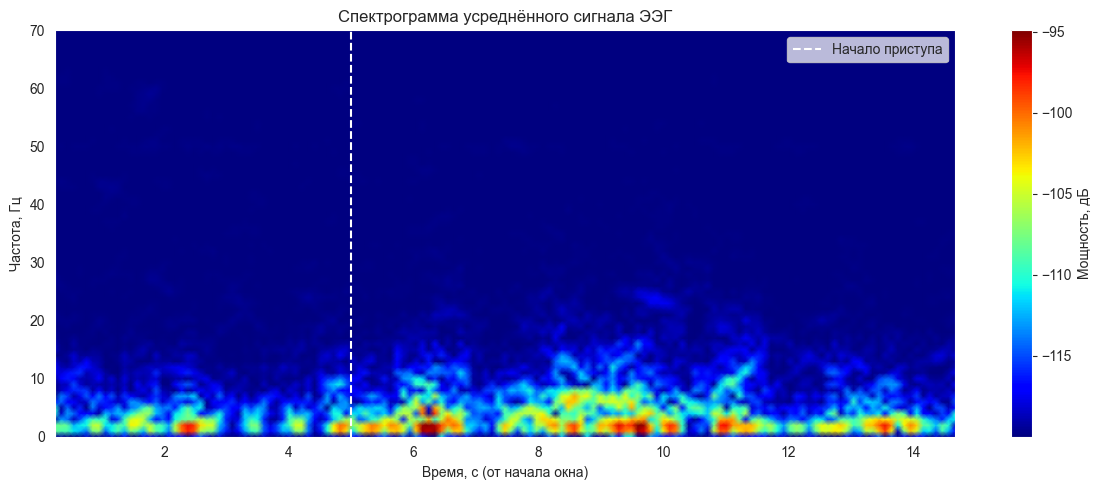

In [15]:
# ========== Ячейка 7: Спектрограмма ==========
print("Вычисление спектрограммы...")
f, t_spec, Sxx = spectrogram(signal_crop_avg, fs=sfreq,
                              nperseg=int(sfreq * 0.5),  # окно 0.5 сек
                              noverlap=int(sfreq * 0.4),
                              nfft=int(sfreq * 1.0))

# Ограничим отображаемый диапазон частот до 70 Гц
freq_mask = f <= 70

plt.figure()
plt.pcolormesh(t_spec, f[freq_mask], 10 * np.log10(Sxx[freq_mask] + 1e-12),
               shading='gouraud', cmap='jet')
plt.axvline(seizure_onset - t_min, color='white', linestyle='--',
            label='Начало приступа')
plt.xlabel('Время, с (от начала окна)')
plt.ylabel('Частота, Гц')
plt.title('Спектрограмма усреднённого сигнала ЭЭГ')
plt.colorbar(label='Мощность, дБ')
plt.legend()
plt.tight_layout()
plt.show()

Вычисление вейвлет-преобразования...


C:\Users\gsdasddj\AppData\Local\Temp\ipykernel_1752\1349411773.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


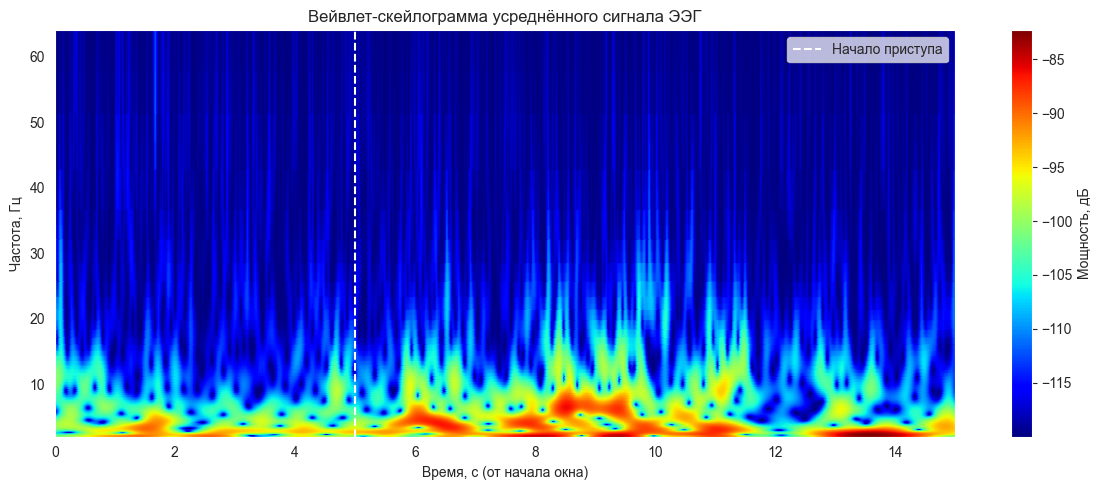

Все вычисления завершены. Графики построены.


In [10]:
# ========== Ячейка 8: Вейвлет-преобразование (скейлограмма) ==========
print("Вычисление вейвлет-преобразования...")
# Непрерывное вейвлет-преобразование
coefficients, frequencies_wt = pywt.cwt(signal_crop_avg, SCALES, WAVELET,
                                        sampling_period=1.0/sfreq)
power_wt = np.abs(coefficients) ** 2  # мощность

# Ограничение по частоте для наглядности
mask_wt = (frequencies_wt >= 0.5) & (frequencies_wt <= 65)

plt.figure()
plt.pcolormesh(times_crop_avg - t_min,   # время от начала окна
               frequencies_wt[mask_wt],
               10 * np.log10(power_wt[mask_wt] + 1e-12),
               shading='gouraud', cmap='jet')
plt.axvline(seizure_onset - t_min, color='white', linestyle='--',
            label='Начало приступа')
plt.xlabel('Время, с (от начала окна)')
plt.ylabel('Частота, Гц')
plt.title('Вейвлет-скейлограмма усреднённого сигнала ЭЭГ')
plt.colorbar(label='Мощность, дБ')
plt.legend()
plt.tight_layout()
plt.show()

print("Все вычисления завершены. Графики построены.")